. Trình bày trong bài thuyết trình
Slide 1: Lý thuyết Gradient Boosting

Gradient Boosting là một thuật toán học máy dựa trên cây quyết định, xây dựng mô hình bằng cách kết hợp nhiều cây yếu (weak learners).
Mỗi cây mới được thêm vào để giảm thiểu sai số của mô hình hiện tại bằng cách tối ưu hóa hàm mất mát (loss function).
Ưu điểm:
Hiệu suất cao với dữ liệu phi tuyến tính.
Khả năng tự động chọn lọc đặc trưng.
Nhược điểm:
Cần tinh chỉnh siêu tham số.
Tốn thời gian huấn luyện hơn so với các mô hình đơn giản.
Slide 2: Quy trình thực nghiệm

Bước 1: Chuẩn bị dữ liệu (xử lý dữ liệu, mã hóa, chia tập).
Bước 2: Huấn luyện mô hình với XGBoost.
Bước 3: Đánh giá mô hình bằng các metrics (MAE, RMSE, R²).
Bước 4: So sánh kết quả với các mô hình khác.
Slide 3: Kết quả và nhận xét

Trình bày bảng hoặc biểu đồ so sánh các metrics giữa Gradient Boosting và các mô hình khác.
Giải thích tại sao Gradient Boosting hoạt động tốt (hoặc không tốt) với dữ liệu của bạn.

In [138]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, train_test_split
import json
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


def target_encode_kfold(df, column, target, n_fold=5, alpha=5):
    """
    Performs target encoding with k-fold cross-validation to prevent data leakage.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataframe containing the data
    column : str
        The name of the categorical column to encode
    target : str
        The name of the target column
    n_fold : int, default=5
        Number of folds for cross-validation
    alpha : float, default=5
        Regularization parameter
        
    Returns:
    --------
    pandas Series
        The encoded values for the column
    """
    # Create a copy of the dataframe
    df_copy = df.copy()
    
    # Calculate the global mean
    global_mean = df_copy[target].mean()
    
    # Create the output Series
    encoded = pd.Series(index=df_copy.index)
    
    # Split the data into n_fold parts
    kf = KFold(n_splits=n_fold, shuffle=True, random_state=42)
    
    for train_idx, test_idx in kf.split(df_copy):
        # Calculate the mean target for each category in the training fold
        means = df_copy.iloc[train_idx].groupby(column)[target].agg(['mean', 'count'])
        
        # Apply regularization
        smoothed_means = ((means['mean'] * means['count']) + (global_mean * alpha)) / (means['count'] + alpha)
        
        # Map the means to the test fold
        encoded.iloc[test_idx] = df_copy.iloc[test_idx][column].map(smoothed_means)
    
    # Handle any categories that weren't seen in the training data (use global mean)
    encoded.fillna(global_mean, inplace=True)
    
    return encoded

In [139]:
# Đọc dữ liệu đã mã hóa
train_file = '../../data/datasets/train_stratified_by_chip_model.csv'
test_file = '../../data/datasets/test_stratified_by_chip_model.csv'

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

# Các cột cần encoding và cột mục tiêu
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']
target_col = 'price'

# Lưu lại mean của các categorical features
encoding_means = {}
encoding_means_path = './datasets/encoding_means.json'

for col in categorical_cols:
    print(f"Encoding {col}...")
    train_df[f'{col}_encoded'] = target_encode_kfold(
        train_df, column=col, target=target_col, n_fold=5, alpha=10
    )
    # Lưu mean của từng category
    encoding_means[col] = train_df.groupby(col)[f'{col}_encoded'].mean().to_dict()

# Lưu encoding_means vào file JSON
with open(encoding_means_path, 'w') as f:
    json.dump(encoding_means, f)
print(f"Saved encoding means to ${encoding_means_path}")

# Áp dụng encoding cho tập test
for col in categorical_cols:
    test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())

# Các cột đặc trưng và biến mục tiêu
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
target = 'price'

print(f"Features: {features}")

# Chuẩn bị dữ liệu
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Huấn luyện mô hình Gradient Boosting
model = GradientBoostingRegressor(
    learning_rate=0.005,
    n_estimators=500,
    max_depth=6,
    random_state=42,
)
model.fit(X_train, y_train)

# Lưu mô hình vào file
joblib.dump(model, 'gradient_boosting_model.pkl')
print("Saved model to 'gradient_boosting_model.pkl'")

# Dự đoán trên tập test
y_pred = model.predict(X_test)

# Đánh giá mô hình
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

Encoding chip_model...
Encoding brand...
Encoding screen_tech...
Encoding screen_resolution_k...
Saved encoding means to $./datasets/encoding_means.json
Features: ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 'camera_main_resolution', 'camera_count', 'chip_model_encoded', 'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
Saved model to 'gradient_boosting_model.pkl'
Mean Absolute Error (MAE): 2539477.440115203
Root Mean Squared Error (RMSE): 3671183.90540385
R² Score: 0.8123789174618387


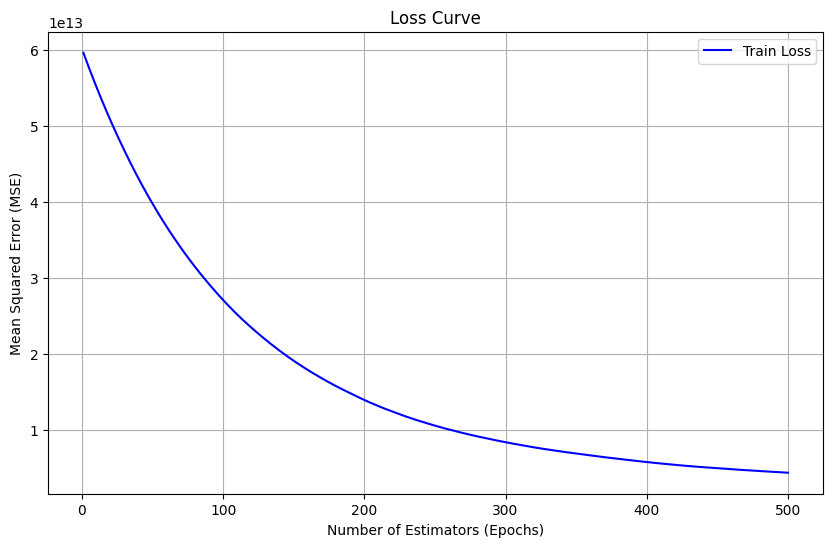

In [140]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Tính loss (MSE) trên tập train qua từng vòng lặp
train_loss = model.train_score_

# # Tính loss (MSE) trên tập test qua từng vòng lặp
# test_loss = []
# for y_pred in model.staged_predict(X_test):
#     test_loss.append(mean_squared_error(y_test, y_pred))

# Trực quan hóa loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss', color='blue')
# plt.plot(range(1, len(test_loss) + 1), test_loss, label='Test Loss', color='orange')
plt.xlabel('Number of Estimators (Epochs)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Loss Curve')
plt.legend()
plt.grid()
plt.show()

Test

In [141]:
import pandas as pd
import joblib
import json

# Đường dẫn đến file trọng số và encoding means
model_file = 'gradient_boosting_model.pkl'
encoding_means_file = './datasets/encoding_means.json'

# Tải mô hình đã lưu
model = joblib.load(model_file)
print("Model loaded successfully!")

# Tải encoding means
with open(encoding_means_file, 'r') as f:
    encoding_means = json.load(f)
print("Encoding means loaded successfully!")

# Đọc tập test
test_file = '../../data/datasets/test_stratified_by_chip_model.csv'
test_df = pd.read_csv(test_file)

# Các cột cần mã hóa
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']

# Áp dụng encoding cho tập test
for col in categorical_cols:
    test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(0)

# Các cột đặc trưng
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']

# Chuẩn bị dữ liệu
X_test = test_df[features]

# Dự đoán
y_pred = model.predict(X_test)

# Lưu kết quả dự đoán
test_df['predicted_price'] = y_pred
output_file = 'test_predictions.csv'
test_df.to_csv(output_file, index=False)
print(f"Predictions saved to {output_file}")

Model loaded successfully!
Encoding means loaded successfully!
Predictions saved to test_predictions.csv


### 1. Trực quan hóa hiệu suất mô hình
- a. Biểu đồ so sánh giá trị thực tế và giá trị dự đoán
    - Mục đích: Để kiểm tra mức độ khớp giữa giá trị thực tế (y_test) và giá trị dự đoán (y_pred).
    - Cách thực hiện:

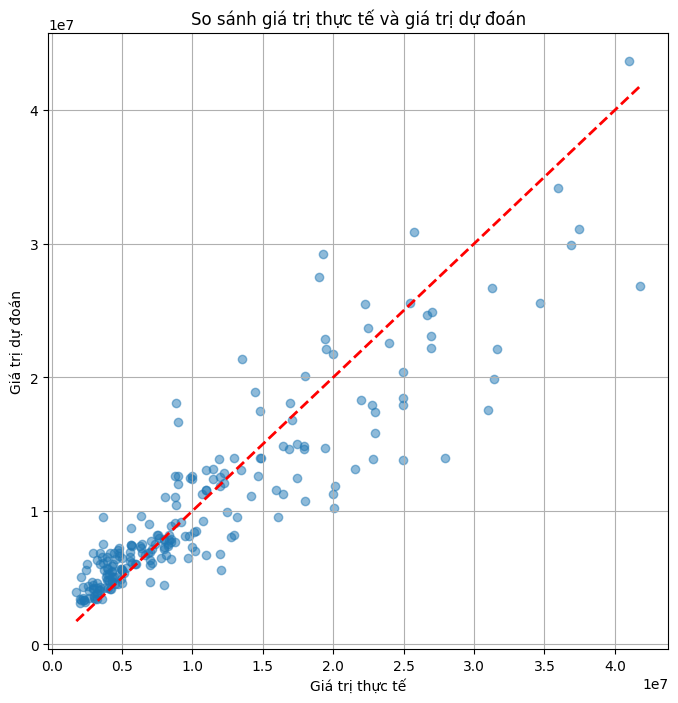

In [142]:
import matplotlib.pyplot as plt
import numpy as np

# Biểu đồ scatter giữa giá trị thực tế và giá trị dự đoán
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('So sánh giá trị thực tế và giá trị dự đoán')
plt.grid()
plt.show()

b. Biểu đồ phân phối sai số (Residual Plot)
- Mục đích: Để kiểm tra xem sai số có phân phối ngẫu nhiên hay không.
- Cách thực hiện:

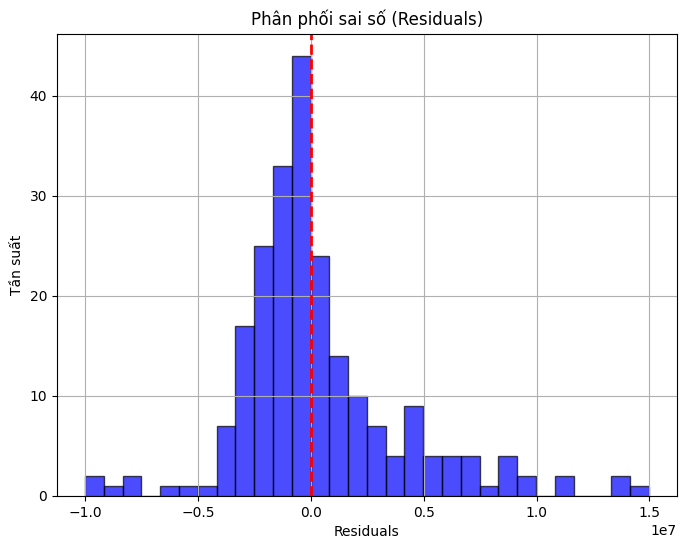

In [143]:
# Tính residuals
residuals = y_test - y_pred

# Biểu đồ phân phối residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals')
plt.ylabel('Tần suất')
plt.title('Phân phối sai số (Residuals)')
plt.grid()
plt.show()

### 2. Trực quan hóa tầm quan trọng của đặc trưng (Feature Importance)
- Mục đích: Để hiểu đặc trưng nào đóng vai trò quan trọng nhất trong việc dự đoán.
- Cách thực hiện:

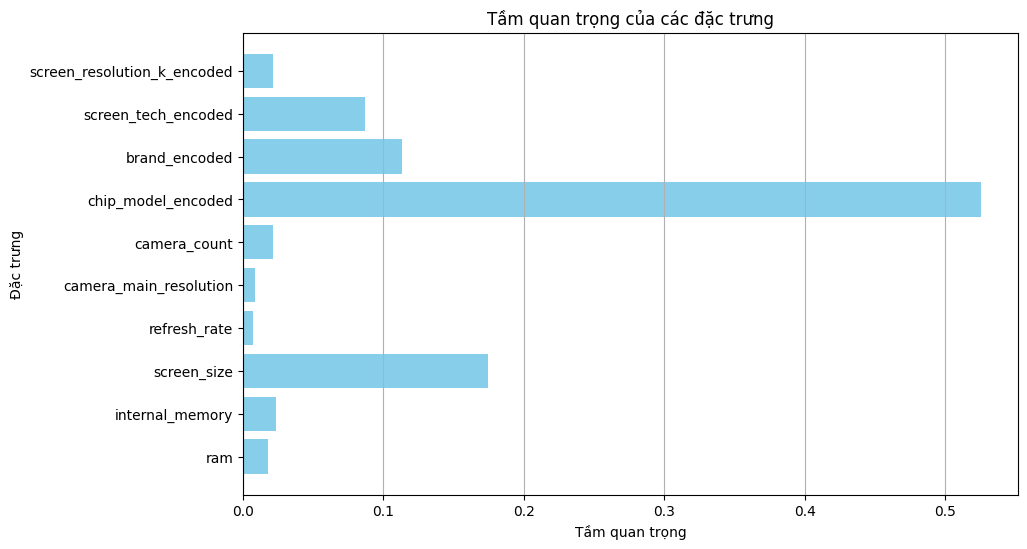

In [144]:
# Lấy tầm quan trọng của đặc trưng từ mô hình
feature_importances = model.feature_importances_
feature_names = features

# Biểu đồ cột cho tầm quan trọng của đặc trưng
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances, color='skyblue')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.title('Tầm quan trọng của các đặc trưng')
plt.grid(axis='x')
plt.show()

### 3. Trực quan hóa mối quan hệ giữa đặc trưng và giá trị mục tiêu
- a. Biểu đồ scatter giữa đặc trưng quan trọng nhất và giá trị mục tiêu
    - Mục đích: Để kiểm tra mối quan hệ giữa đặc trưng quan trọng nhất và giá trị mục tiêu (price).
    - Cách thực hiện:

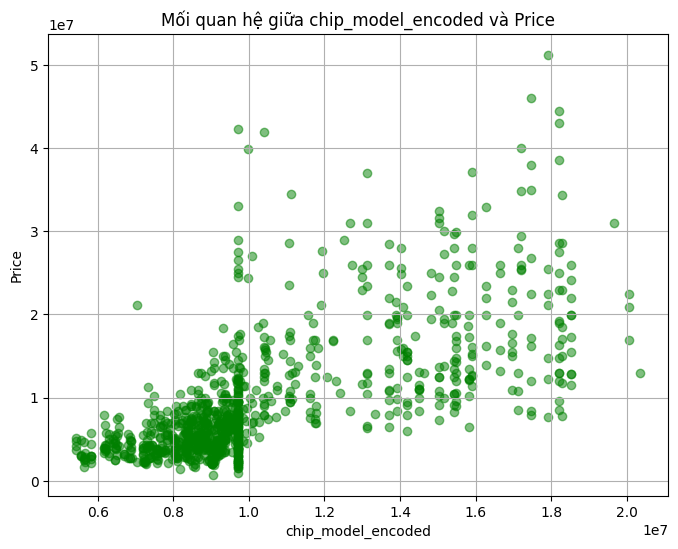

In [145]:
# Chọn đặc trưng quan trọng nhất
most_important_feature = feature_names[np.argmax(feature_importances)]

# Biểu đồ scatter
plt.figure(figsize=(8, 6))
plt.scatter(train_df[most_important_feature], train_df[target], alpha=0.5, color='green')
plt.xlabel(most_important_feature)
plt.ylabel('Price')
plt.title(f'Mối quan hệ giữa {most_important_feature} và Price')
plt.grid()
plt.show()

### 4. Trực quan hóa phân phối giá trị thực tế và giá trị dự đoán
- Mục đích: Để kiểm tra xem phân phối của giá trị dự đoán có khớp với giá trị thực tế hay không.
- Cách thực hiện:

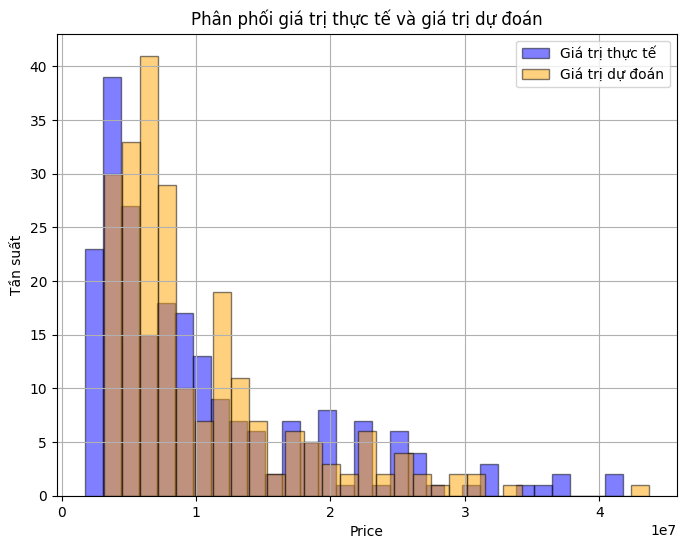

In [146]:
# Biểu đồ phân phối giá trị thực tế và giá trị dự đoán
plt.figure(figsize=(8, 6))
plt.hist(y_test, bins=30, alpha=0.5, label='Giá trị thực tế', color='blue', edgecolor='black')
plt.hist(y_pred, bins=30, alpha=0.5, label='Giá trị dự đoán', color='orange', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Tần suất')
plt.title('Phân phối giá trị thực tế và giá trị dự đoán')
plt.legend()
plt.grid()
plt.show()